In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath("../"))
from utils.gref_pipeline.georef import *

sys.path.append(os.path.abspath("../../"))
from gref_pipeline import config

In [2]:
transect = load_transect(config.OUTPUT_FOLDER)
transect.list_files()


📋 Files in output (corrected=False):
 1. rad_uhi_20241029_115057_1  | shape=(1333, 968, 210)  | has_georef=True
 2. rad_uhi_20241029_115057_2  | shape=(1946, 968, 210)  | has_georef=True
 3. rad_uhi_20241029_115057_3  | shape=(2227, 968, 210)  | has_georef=True
 4. rad_uhi_20241029_115057_4  | shape=(2463, 968, 210)  | has_georef=True
 5. rad_uhi_20241029_115057_5  | shape=(2462, 968, 210)  | has_georef=True
 6. rad_uhi_20241029_115057_6  | shape=(155, 968, 210)  | has_georef=True


In [3]:
cube = transect.select_files(
    [
        # "rad_uhi_20241029_115057_4",
        "rad_uhi_20241029_115057_5",
    ]
)
cube.describe()

🔄 Rebuilding grids from georef hits for selected files...
   • rad_uhi_20241029_115057_5
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
✅ Combined shapes: X/Y/Z (2462, 968), RGB (2462, 968)
🔄 Loading full hyperspectral cube...
   • Loading rad_uhi_20241029_115057_5...
✅ Combined shapes: X/Y/Z (2462, 968), RGB (2462, 968)
🔄 Loading full hyperspectral cube...
   • Loading rad_uhi_20241029_115057_5...
✅ Combined shapes: X/Y/Z (2462, 968), RGB (2462, 968)
🔄 Loading full hyperspectral cube...
   • Loading rad_uhi_20241029_115057_5...


✅ Loaded full cube: (2462, 968, 210) (T × S × B)

=== Combined_output ===
Tracks × Slits: 2462 × 968
RGB coverage: R/G/B finite ratios 1.00/1.00/1.00

📋 File boundaries:
  rad_uhi_20241029_115057_5: tracks 0–2461 (2462)


In [4]:
cube.list_saved_corrections()


📋 Cached illumination corrections:

📁 File: rad_uhi_20241029_115057_5
   ✓ window=1000, strength=1.0
     Dataset: dataCube_illum_corrected_w1000_s1p00
     Shape: (2462, 968, 210), Size: 1909.2 MB
   ✓ window=500, strength=1.0
     Dataset: dataCube_illum_corrected_w500_s1p00
     Shape: (2462, 968, 210), Size: 1909.2 MB
   ✓ window=750, strength=1.0
     Dataset: dataCube_illum_corrected_w750_s1p00
     Shape: (2462, 968, 210), Size: 1909.2 MB


In [5]:
# Apply illumination correction with rolling window (window_size=1000 tracks)
# NOTE: Using V2 version (pandas rolling median, no scipy bugs)
# This will be cached to disk - next time it will load instantly!
# Use force_recompute=True to force recalculation
cube.apply_illumination_correction_v2(window_size=750, force_recompute=False)

🔄 Using V2 algorithm (pandas rolling median)
✅ Illumination correction already applied with window=750, strength=1.0
   Loading from disk...
📂 Loading saved illumination correction from 1 files...
   rad_uhi_20241029_115057_5: window=750, strength=1.0
✅ Loaded illumination correction from disk
   rad_uhi_20241029_115057_5: window=750, strength=1.0
✅ Loaded illumination correction from disk
   rad_uhi_20241029_115057_5: window=750, strength=1.0
✅ Loaded illumination correction from disk


array([[[2.2304249e+00, 1.6764377e+00, 0.0000000e+00, ...,
         0.0000000e+00, 7.4917216e+00, 0.0000000e+00],
        [7.4757171e+00, 8.5974735e-01, 0.0000000e+00, ...,
         0.0000000e+00, 3.0958059e+00, 0.0000000e+00],
        [1.8294926e+00, 2.3438740e+00, 0.0000000e+00, ...,
         0.0000000e+00, 7.8464627e+00, 0.0000000e+00],
        ...,
        [1.7213115e+00, 1.4317783e+00, 0.0000000e+00, ...,
         1.0000000e+00, 2.3279436e-02, 3.9091909e-01],
        [5.1958108e+00, 2.2674298e+00, 0.0000000e+00, ...,
         0.0000000e+00, 1.9884717e+00, 0.0000000e+00],
        [2.3867478e+00, 1.0517330e+00, 0.0000000e+00, ...,
         0.0000000e+00, 2.4243166e+01, 5.2279919e-01]],

       [[2.2304249e+00, 7.7452070e-01, 3.9940205e+00, ...,
         0.0000000e+00, 0.0000000e+00, 9.6023534e-05],
        [1.7471981e+00, 0.0000000e+00, 1.2654871e+00, ...,
         0.0000000e+00, 8.5029960e-01, 7.2527355e-01],
        [1.9216584e+00, 0.0000000e+00, 3.0771544e+00, ...,
         0.000

In [6]:
cube.adjust_uhi_alignment(dx=-0.05, dy=-3.0)

✅ UHI alignment adjusted:
   dx (East):  -0.050 m
   dy (North): -3.000 m

💡 This will be applied in plot_georef() with coordinate_system='NED'


In [49]:
# Import ROIs from file
cube.import_rois("my_rois_6.json")

📂 Imported 18 ROIs from my_rois_6.json


In [8]:
# List all ROIs
cube.list_rois()


📂 ROI Collection (16 ROIs):
 1. 'dark sediment': 120 pixels
     Slit range:  254 - 325
     Track range: 931 - 1416
 2. 'dark1': 98 pixels
     Slit range:  606 - 740
     Track range: 729 - 765
 3. 'dark2': 140 pixels
     Slit range:  174 - 356
     Track range: 1094 - 1148
 4. 'sediment': 273 pixels
     Slit range:   14 - 870
     Track range: 577 - 1580
 5. 'dark bomb': 238 pixels
     Slit range:  174 - 740
     Track range: 729 - 1148
 6. 'tripple bomb 1': 71 pixels
     Slit range:  662 - 701
     Track range: 593 - 598
 7. 'tripple bomb 2': 42 pixels
     Slit range:  639 - 654
     Track range: 700 - 705
 8. 'tripple bomb 3': 84 pixels
     Slit range:  632 - 678
     Track range: 757 - 765
 9. 'single bomb ring': 62 pixels
     Slit range:  224 - 404
     Track range: 1124 - 1168
10. 'single bomb inside': 82 pixels
     Slit range:  244 - 291
     Track range: 1126 - 1135
11. 'double bomb 1': 114 pixels
     Slit range:  809 - 880
     Track range: 1500 - 1516
12. 'double 

In [9]:
# cube.export_rois("my_rois_6.json")

In [10]:
# # Example: Combine multiple ROIs
# cube.combine_rois(
#     roi_names_to_combine=[
#         "single bomb inside",
#         "double bomb 1",
#         "double bomb 2",
#         "tripple bomb 1",
#         "tripple bomb 2",
#         "tripple bomb 3",
#     ],
#     new_roi_name="all bombs",
# )

In [11]:
# cube.rename_roi(old_roi_name="sed1", new_roi_name="Sediment")

💡 Interactive mode: Click on the plot to display coordinates


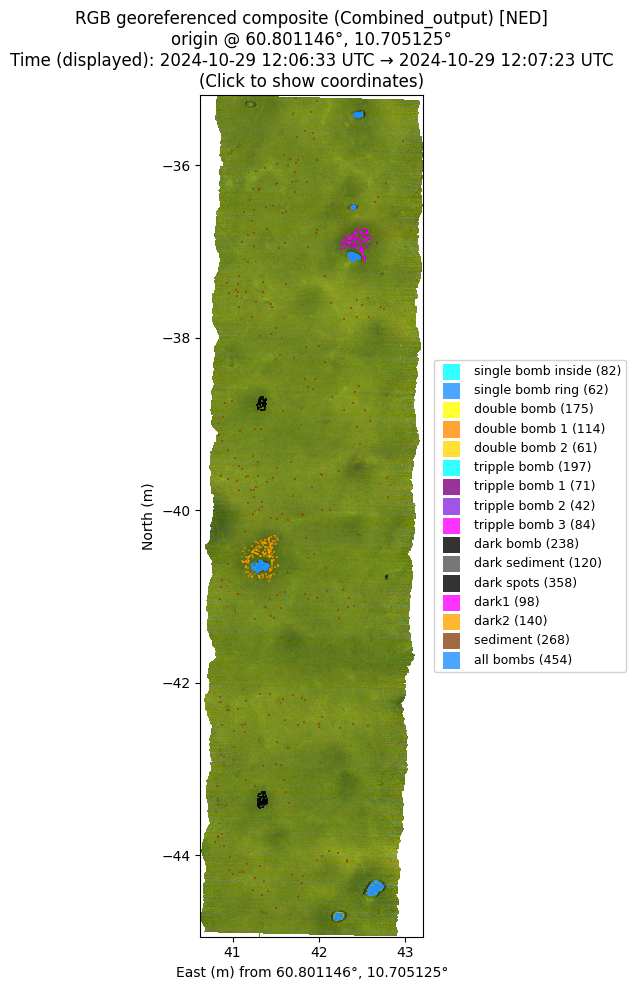

In [12]:
cube.plot_georef(
    apply_alignment_shift=True,
    use_corrected=True,
    coordinate_system="NED",
    track_start=config.UHI_TRACK_RANGE_5[0],
    track_end=config.UHI_TRACK_RANGE_5[1],
    figsize=(30, 10),
    roi_collection="all",
    roi_marker_size=2,
    roi_legend_loc="outside",
    roi_marker_edgewidth=0,
    roi_legend_markersize=50,
)

In [50]:
roi_extra = [
    "sediment",
    "dark spots",
    "all bombs",
    "brown leaf",
    "yellow leaf",
]

In [13]:
roi_totals = [
    "sediment",
    "dark spots",
    "all bombs",
]

💡 Interactive mode: Click on the plot to display coordinates


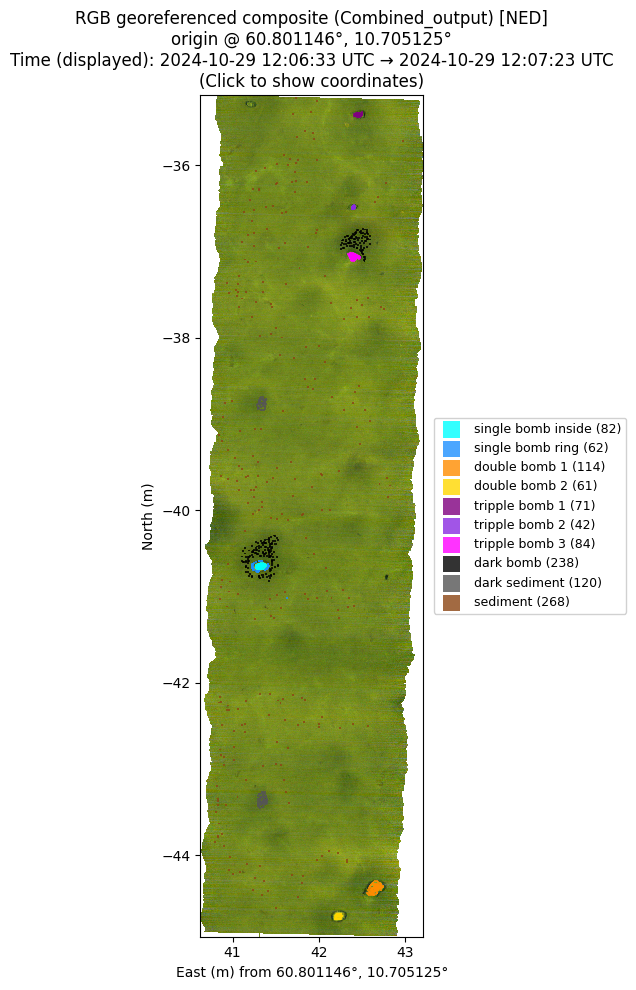

In [14]:
roi_names = [
    "double bomb 2",
    "double bomb 1",
    "tripple bomb 1",
    "tripple bomb 2",
    "tripple bomb 3",
    "single bomb ring",
    "single bomb inside",
    "dark sediment",
    "dark bomb",
    "sediment",
]


cube.plot_georef(
    apply_alignment_shift=True,
    use_corrected=True,
    coordinate_system="NED",
    track_start=config.UHI_TRACK_RANGE_5[0],
    track_end=config.UHI_TRACK_RANGE_5[1],
    figsize=(30, 10),
    roi_collection=roi_names,
    roi_marker_size=2,
    roi_legend_loc="outside",
    roi_marker_edgewidth=0,
    roi_legend_markersize=50,
)

💡 Interactive mode: Click on the plot to display coordinates


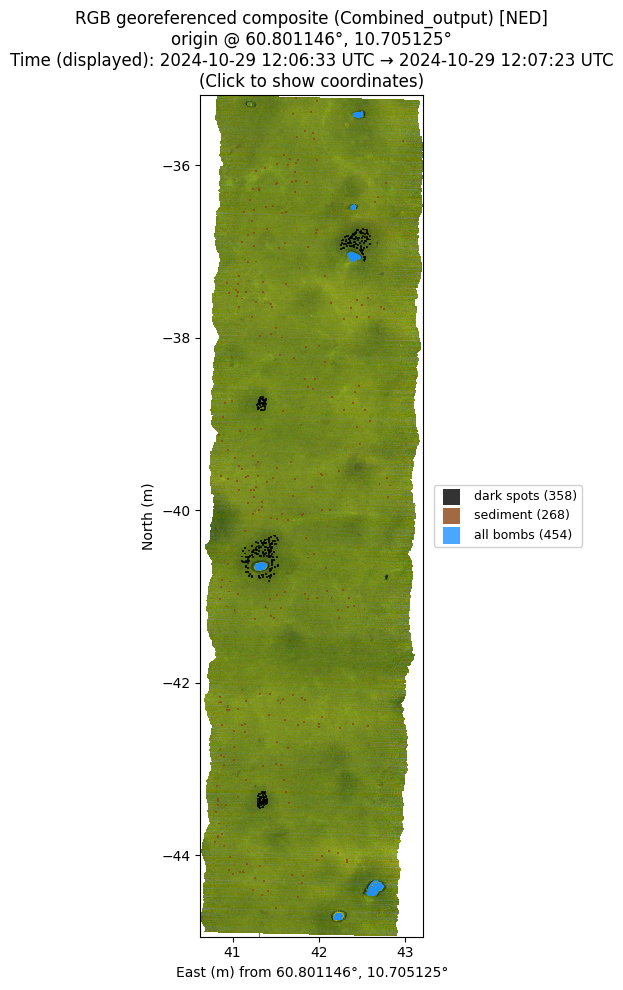

In [15]:
cube.plot_georef(
    apply_alignment_shift=True,
    use_corrected=True,
    coordinate_system="NED",
    track_start=config.UHI_TRACK_RANGE_5[0],
    track_end=config.UHI_TRACK_RANGE_5[1],
    figsize=(30, 10),
    roi_collection=roi_totals,
    roi_marker_size=2,
    roi_legend_loc="outside",
    roi_marker_edgewidth=0,
    roi_legend_markersize=50,
)


🔧 Interpolating 3 wavelength(s):
   • Index 35: 440.31 nm
   • Index 104: 559.97 nm
   • Index 157: 654.20 nm



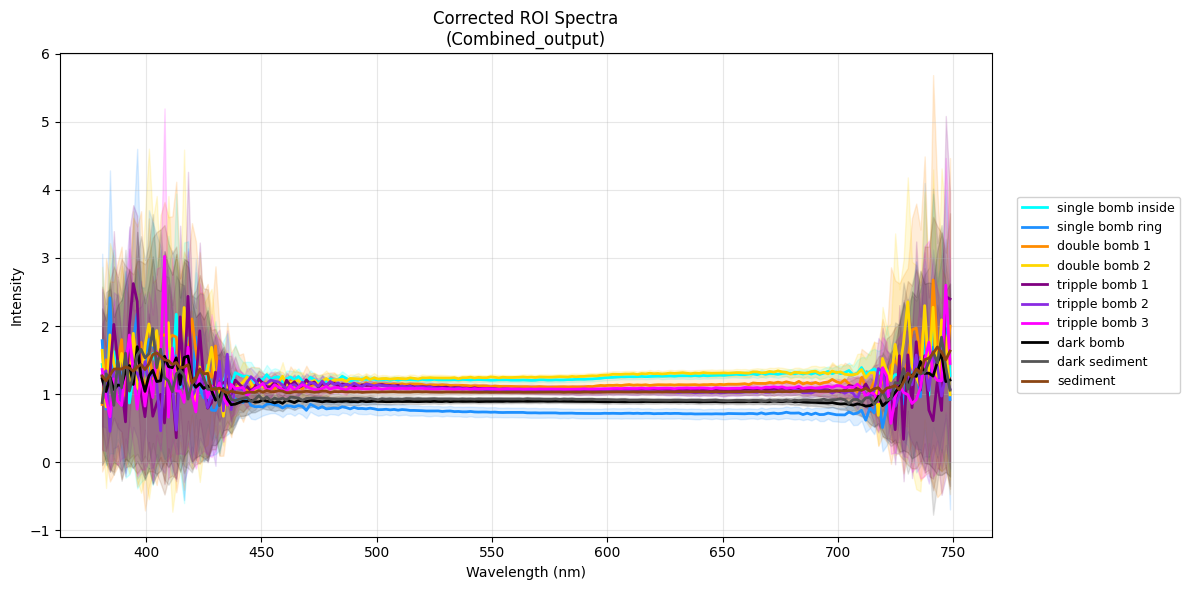

In [16]:
# All ROI spectra with std bands
# Note: ROI colors are now hardcoded in the class!
cube.plot_spectrum(
    roi_names=roi_names,
    use_corrected=True,
    # wavelength_range=(475, 675),
    wavelength_smoothing=0,
    interpolate_wavelengths=[35, 104, 157],
    legend_loc="outside",
    use_inline_labels=False,
)


🔧 Interpolating 3 wavelength(s):
   • Index 35: 440.31 nm
   • Index 104: 559.97 nm
   • Index 157: 654.20 nm



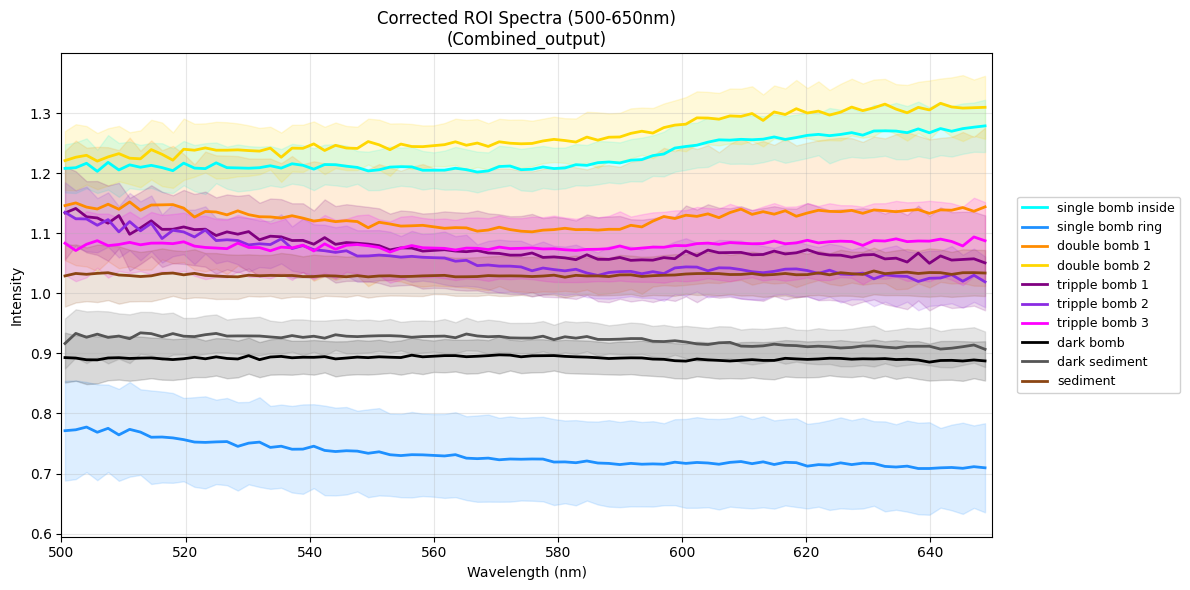

In [17]:
# Test: No normalization (raw data with offset visible)
cube.plot_spectrum(
    roi_names=roi_names,
    use_corrected=True,
    wavelength_range=(500, 650),
    wavelength_smoothing=1,
    interpolate_wavelengths=[35, 104, 157],
    normalize_method=None,  # No normalization
    legend_loc="outside",
    use_inline_labels=False,
    show_std=True,
)


🔧 Interpolating 3 wavelength(s):
   • Index 35: 440.31 nm
   • Index 104: 559.97 nm
   • Index 157: 654.20 nm



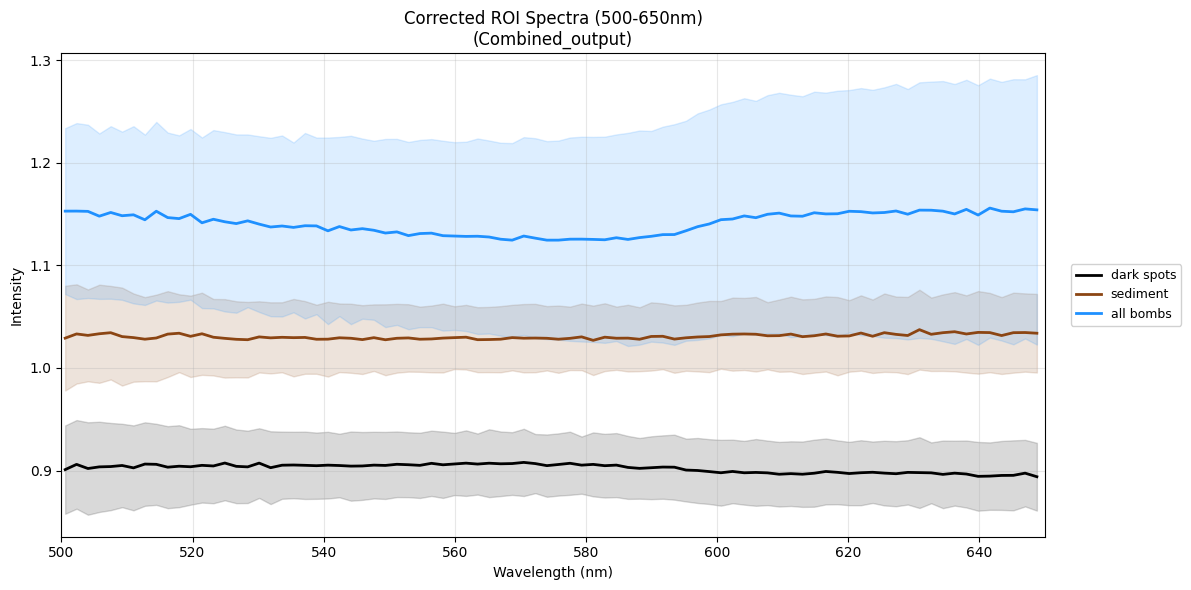

In [18]:
cube.plot_spectrum(
    roi_names=roi_totals,
    use_corrected=True,
    wavelength_range=(500, 650),
    wavelength_smoothing=1,
    interpolate_wavelengths=[35, 104, 157],
    normalize_method=None,  # No normalization
    legend_loc="outside",
    use_inline_labels=False,
)

## 📊 All Normalization Methods - roi_names (individual bombs + sediment)


🔧 Interpolating 3 wavelength(s):
   • Index 35: 440.31 nm
   • Index 104: 559.97 nm
   • Index 157: 654.20 nm



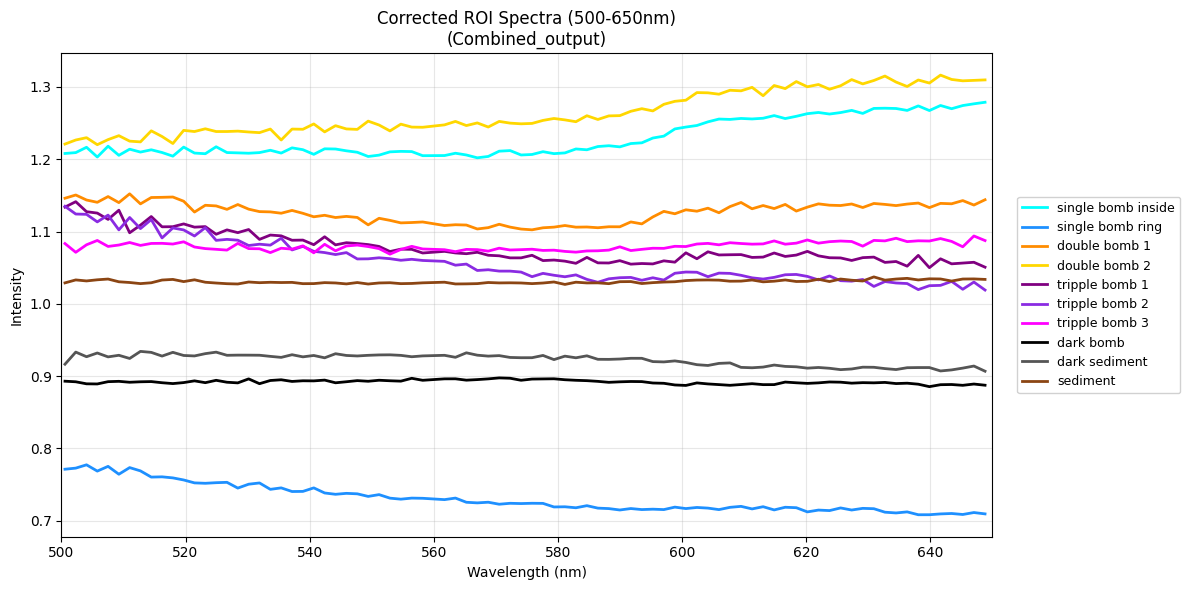

In [19]:
# roi_names: No normalization
cube.plot_spectrum(
    roi_names=roi_names,
    use_corrected=True,
    wavelength_range=(500, 650),
    wavelength_smoothing=1,
    interpolate_wavelengths=[35, 104, 157],
    normalize_method=None,
    legend_loc="outside",
    use_inline_labels=False,
    show_std=False,
)


🔧 Interpolating 3 wavelength(s):
   • Index 35: 440.31 nm
   • Index 104: 559.97 nm
   • Index 157: 654.20 nm



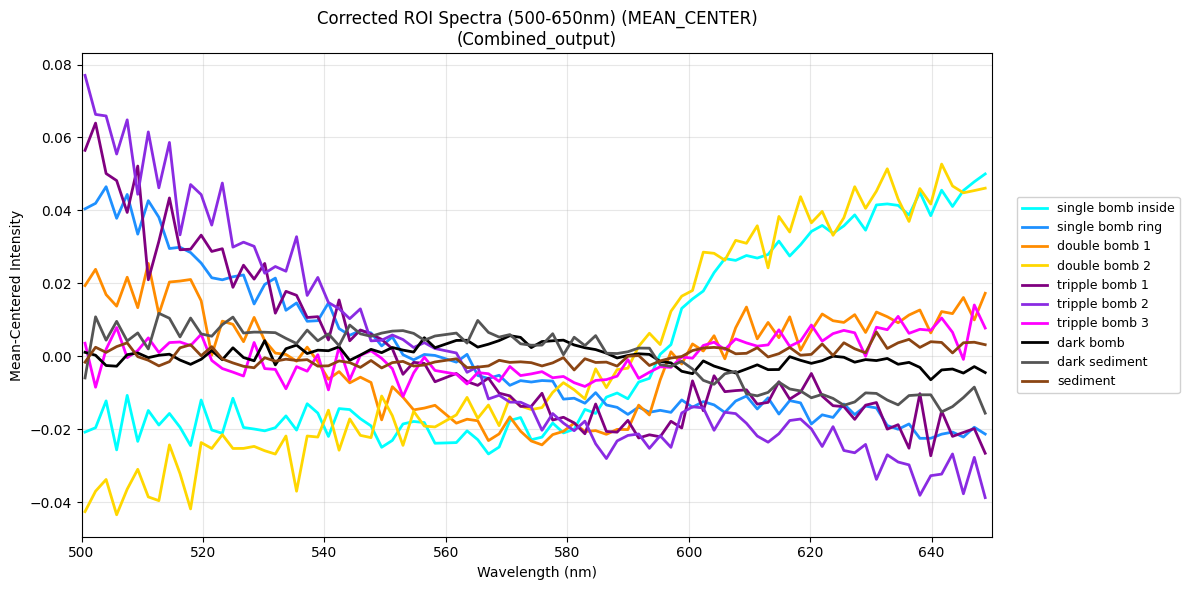

In [20]:
# roi_names: Mean centering ⭐
cube.plot_spectrum(
    roi_names=roi_names,
    use_corrected=True,
    wavelength_range=(500, 650),
    wavelength_smoothing=1,
    interpolate_wavelengths=[35, 104, 157],
    normalize_method="mean_center",
    legend_loc="outside",
    use_inline_labels=False,
    show_std=False,
)


🔧 Interpolating 3 wavelength(s):
   • Index 35: 440.31 nm
   • Index 104: 559.97 nm
   • Index 157: 654.20 nm



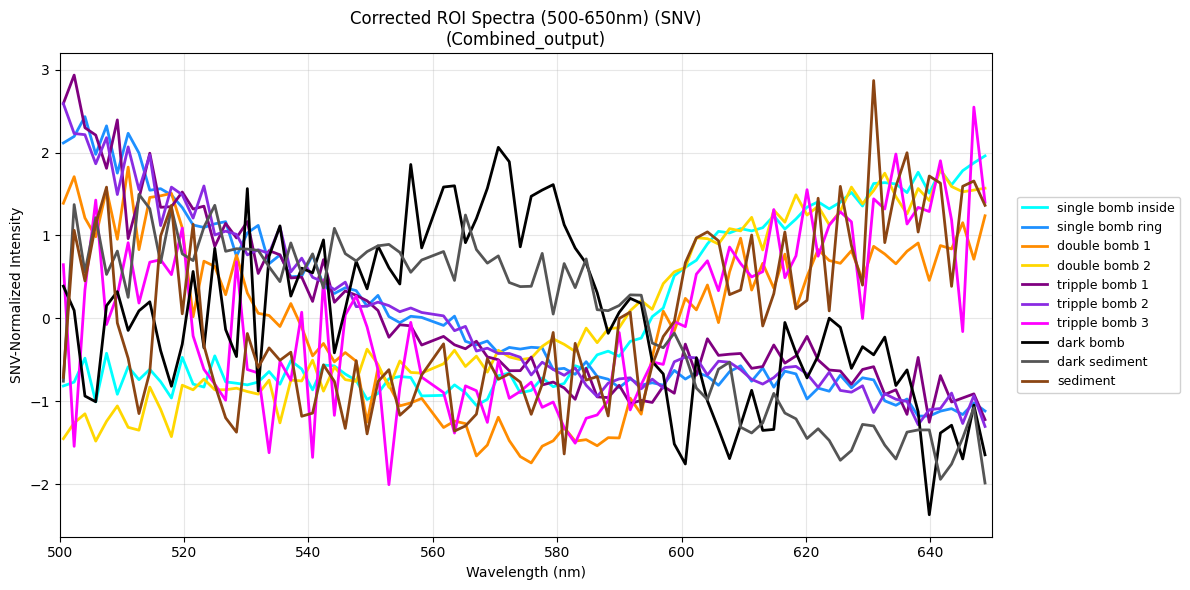

In [21]:
# roi_names: SNV ⭐
cube.plot_spectrum(
    roi_names=roi_names,
    use_corrected=True,
    wavelength_range=(500, 650),
    wavelength_smoothing=1,
    interpolate_wavelengths=[35, 104, 157],
    normalize_method="snv",
    legend_loc="outside",
    use_inline_labels=False,
    show_std=False,
)


🔧 Interpolating 3 wavelength(s):
   • Index 35: 440.31 nm
   • Index 104: 559.97 nm
   • Index 157: 654.20 nm

📊 Computing reference spectrum for MSC normalization...
   ✓ Reference computed from 1147 spectra


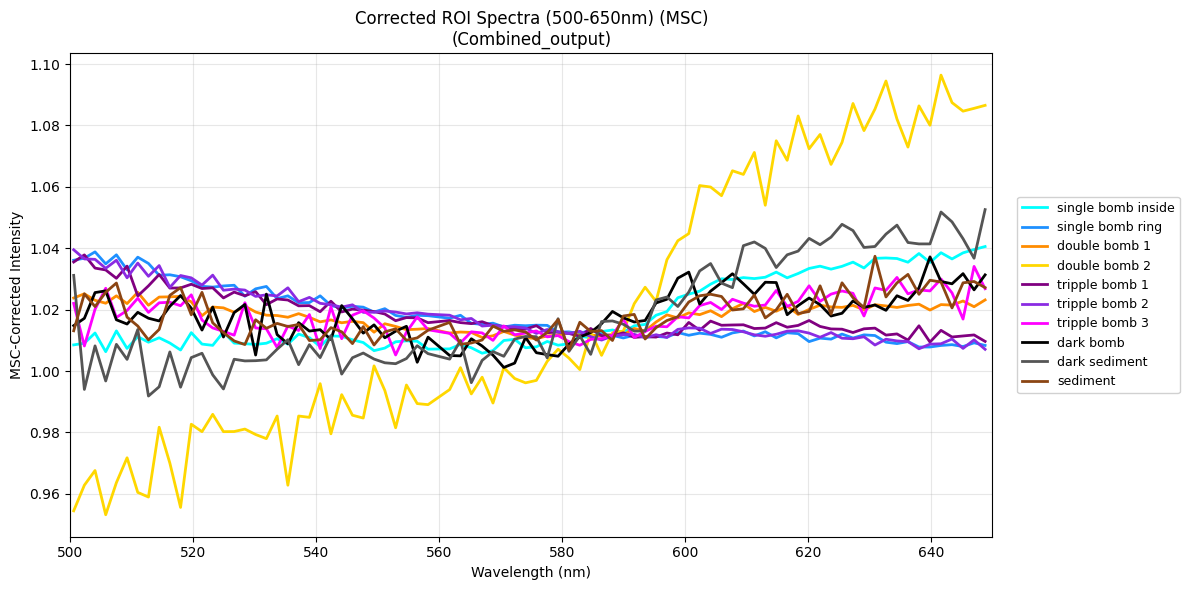

In [22]:
# roi_names: MSC
cube.plot_spectrum(
    roi_names=roi_names,
    use_corrected=True,
    wavelength_range=(500, 650),
    wavelength_smoothing=1,
    interpolate_wavelengths=[35, 104, 157],
    normalize_method="msc",
    legend_loc="outside",
    use_inline_labels=False,
    show_std=False,
)


🔧 Interpolating 3 wavelength(s):
   • Index 35: 440.31 nm
   • Index 104: 559.97 nm
   • Index 157: 654.20 nm



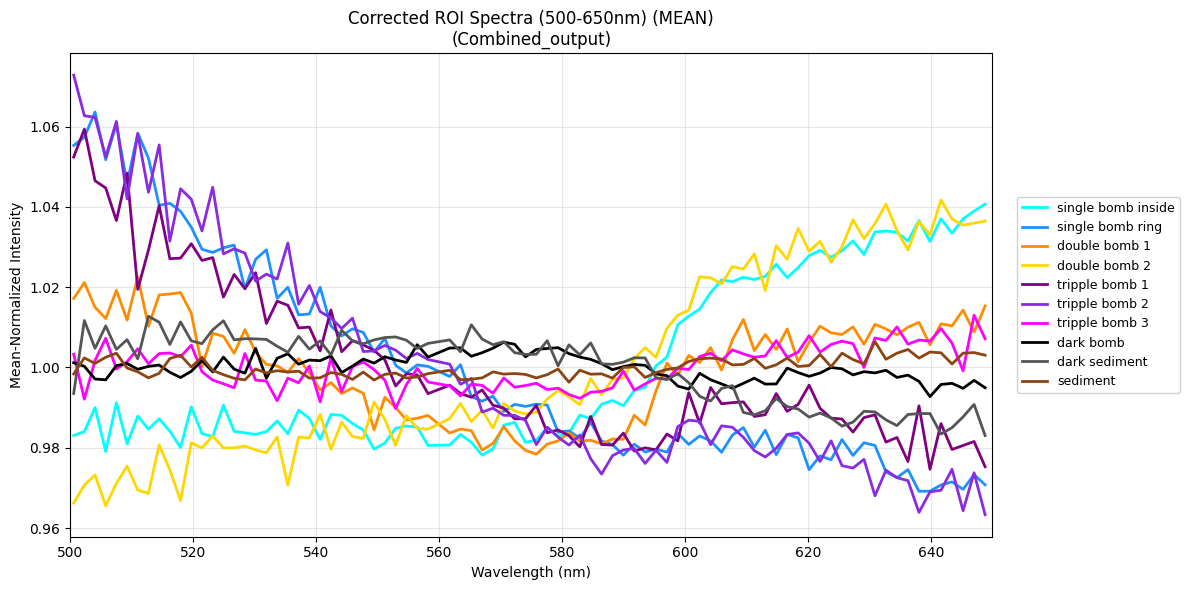

In [23]:
# roi_names: Mean
cube.plot_spectrum(
    roi_names=roi_names,
    use_corrected=True,
    wavelength_range=(500, 650),
    wavelength_smoothing=1,
    interpolate_wavelengths=[35, 104, 157],
    normalize_method="mean",
    legend_loc="outside",
    use_inline_labels=False,
    show_std=False,
)


🔧 Interpolating 3 wavelength(s):
   • Index 35: 440.31 nm
   • Index 104: 559.97 nm
   • Index 157: 654.20 nm



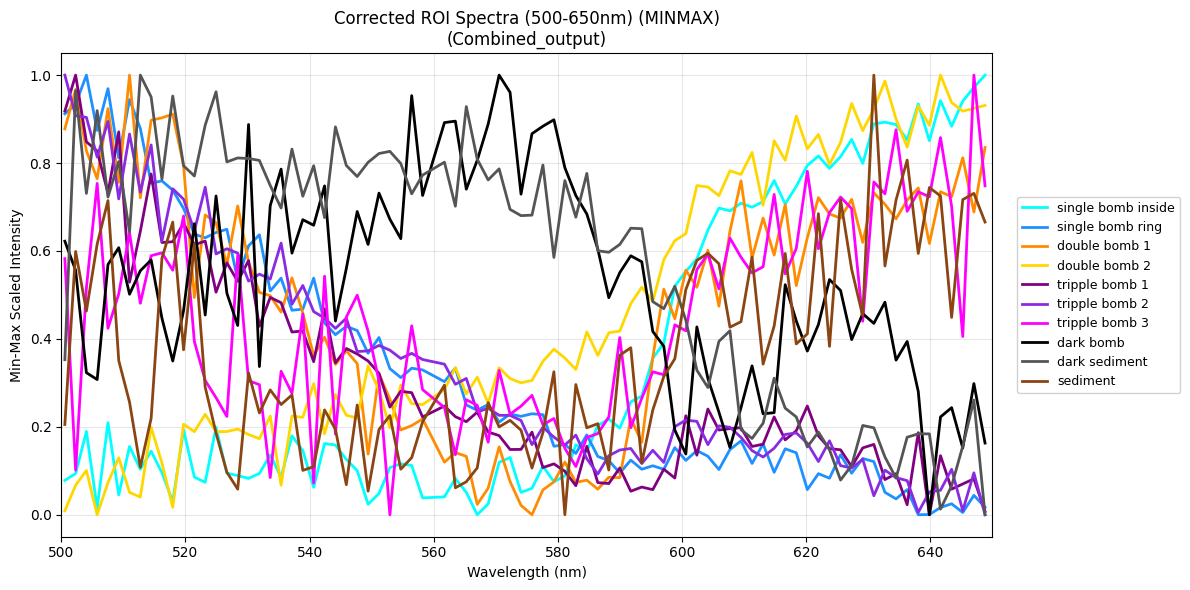

In [24]:
# roi_names: Min-max
cube.plot_spectrum(
    roi_names=roi_names,
    use_corrected=True,
    wavelength_range=(500, 650),
    wavelength_smoothing=1,
    interpolate_wavelengths=[35, 104, 157],
    normalize_method="minmax",
    legend_loc="outside",
    use_inline_labels=False,
    show_std=False,
)


🔧 Interpolating 3 wavelength(s):
   • Index 35: 440.31 nm
   • Index 104: 559.97 nm
   • Index 157: 654.20 nm



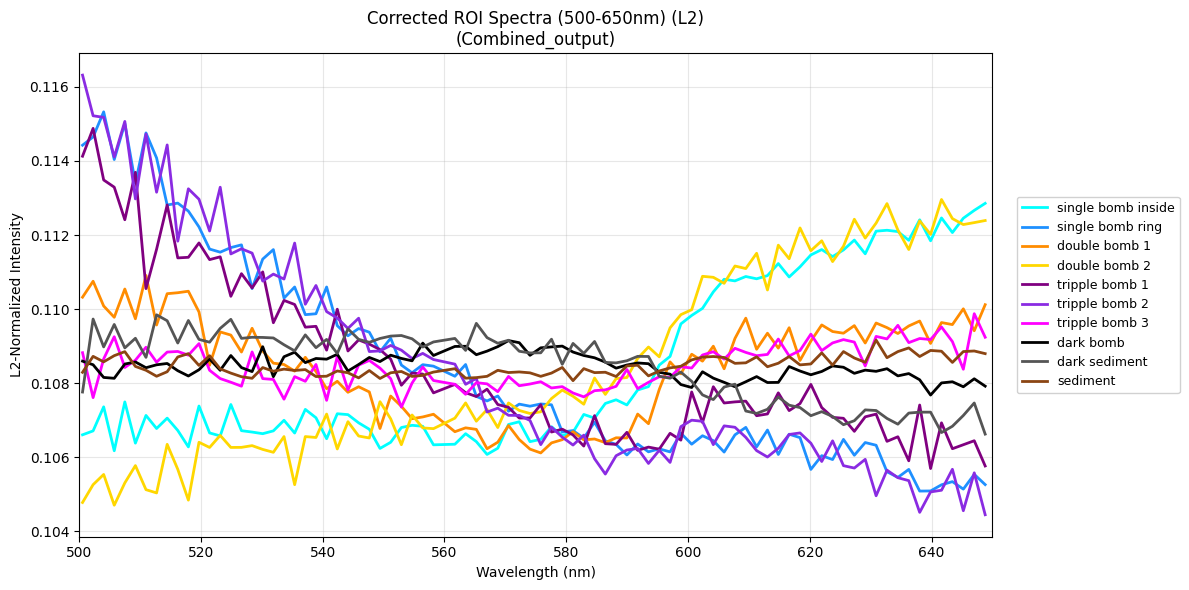

In [25]:
# roi_names: L2
cube.plot_spectrum(
    roi_names=roi_names,
    use_corrected=True,
    wavelength_range=(500, 650),
    wavelength_smoothing=1,
    interpolate_wavelengths=[35, 104, 157],
    normalize_method="l2",
    legend_loc="outside",
    use_inline_labels=False,
    show_std=False,
)

## 📊 All Normalization Methods - roi_totals (grouped: sediment, dark spots, all bombs)


🔧 Interpolating 3 wavelength(s):
   • Index 35: 440.31 nm
   • Index 104: 559.97 nm
   • Index 157: 654.20 nm



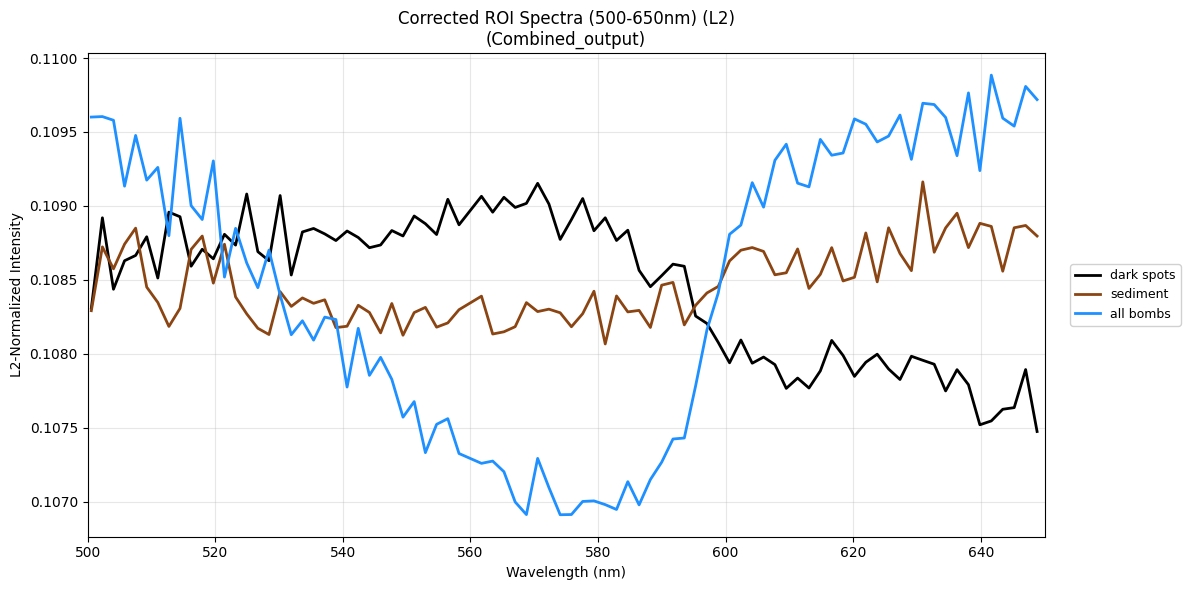

In [26]:
# roi_totals: L2
cube.plot_spectrum(
    roi_names=roi_totals,
    use_corrected=True,
    wavelength_range=(500, 650),
    wavelength_smoothing=1,
    interpolate_wavelengths=[35, 104, 157],
    normalize_method="l2",
    legend_loc="outside",
    use_inline_labels=False,
    show_std=False,
)


🔧 Interpolating 3 wavelength(s):
   • Index 35: 440.31 nm
   • Index 104: 559.97 nm
   • Index 157: 654.20 nm



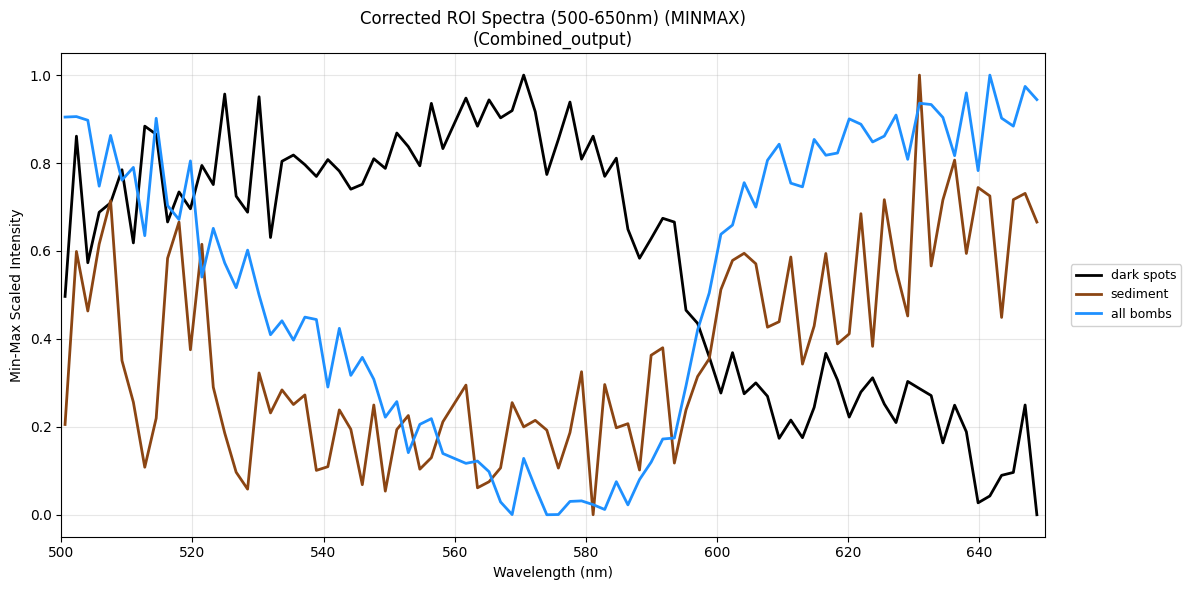

In [27]:
# roi_totals: Min-max
cube.plot_spectrum(
    roi_names=roi_totals,
    use_corrected=True,
    wavelength_range=(500, 650),
    wavelength_smoothing=1,
    interpolate_wavelengths=[35, 104, 157],
    normalize_method="minmax",
    legend_loc="outside",
    use_inline_labels=False,
    show_std=False,
)


🔧 Interpolating 3 wavelength(s):
   • Index 35: 440.31 nm
   • Index 104: 559.97 nm
   • Index 157: 654.20 nm



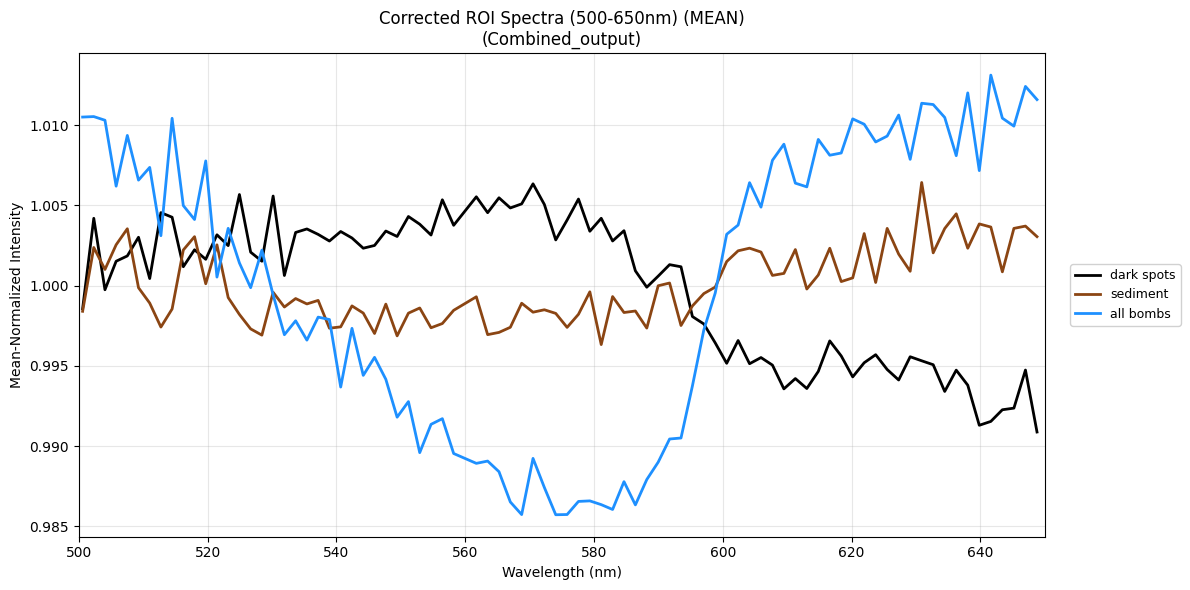

In [28]:
# roi_totals: Mean
cube.plot_spectrum(
    roi_names=roi_totals,
    use_corrected=True,
    wavelength_range=(500, 650),
    wavelength_smoothing=1,
    interpolate_wavelengths=[35, 104, 157],
    normalize_method="mean",
    legend_loc="outside",
    use_inline_labels=False,
    show_std=False,
)


🔧 Interpolating 3 wavelength(s):
   • Index 35: 440.31 nm
   • Index 104: 559.97 nm
   • Index 157: 654.20 nm

📊 Computing reference spectrum for MSC normalization...
   ✓ Reference computed from 1085 spectra


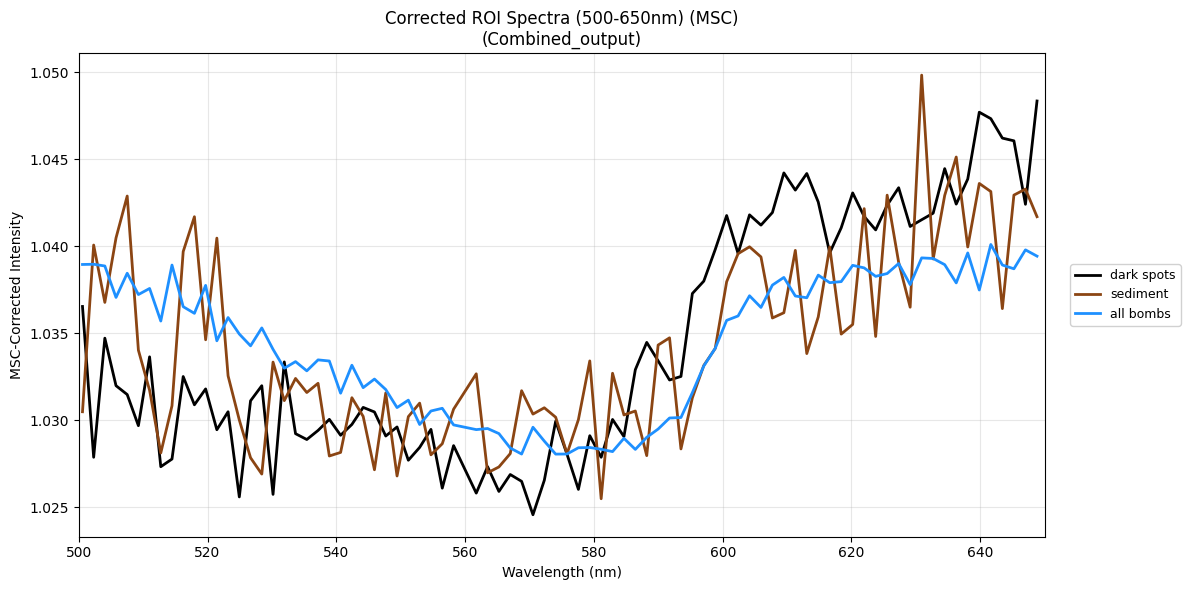

In [29]:
# roi_totals: MSC
cube.plot_spectrum(
    roi_names=roi_totals,
    use_corrected=True,
    wavelength_range=(500, 650),
    wavelength_smoothing=1,
    interpolate_wavelengths=[35, 104, 157],
    normalize_method="msc",
    legend_loc="outside",
    use_inline_labels=False,
    show_std=False,
)


🔧 Interpolating 3 wavelength(s):
   • Index 35: 440.31 nm
   • Index 104: 559.97 nm
   • Index 157: 654.20 nm



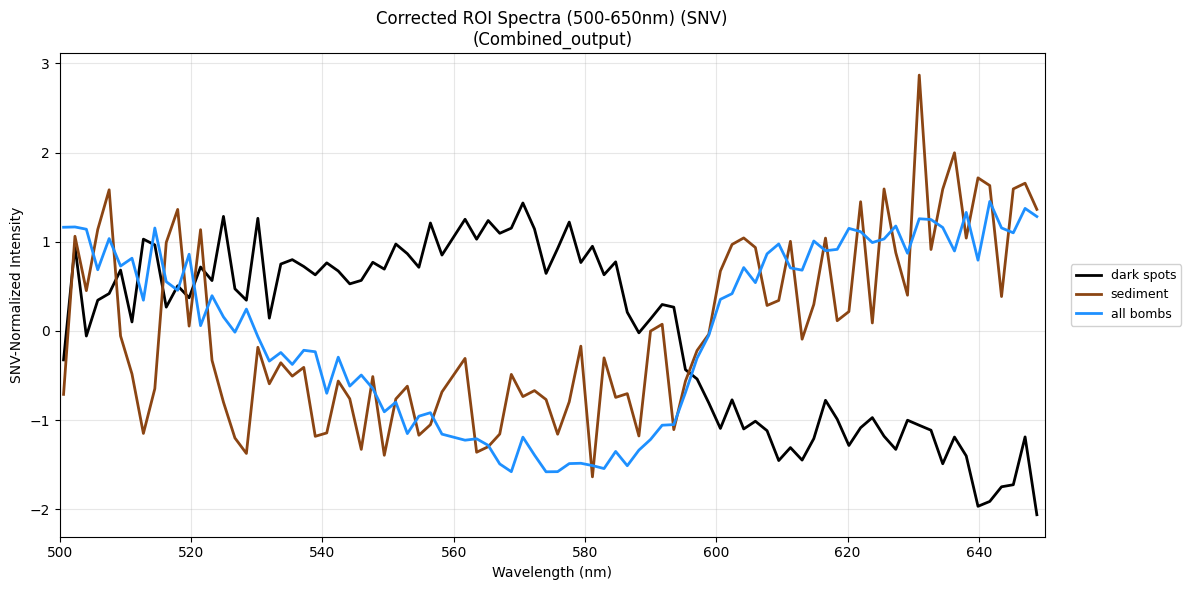

In [30]:
# roi_totals: SNV ⭐
cube.plot_spectrum(
    roi_names=roi_totals,
    use_corrected=True,
    wavelength_range=(500, 650),
    wavelength_smoothing=1,
    interpolate_wavelengths=[35, 104, 157],
    normalize_method="snv",
    legend_loc="outside",
    use_inline_labels=False,
    show_std=False,
)


🔧 Interpolating 3 wavelength(s):
   • Index 35: 440.31 nm
   • Index 104: 559.97 nm
   • Index 157: 654.20 nm



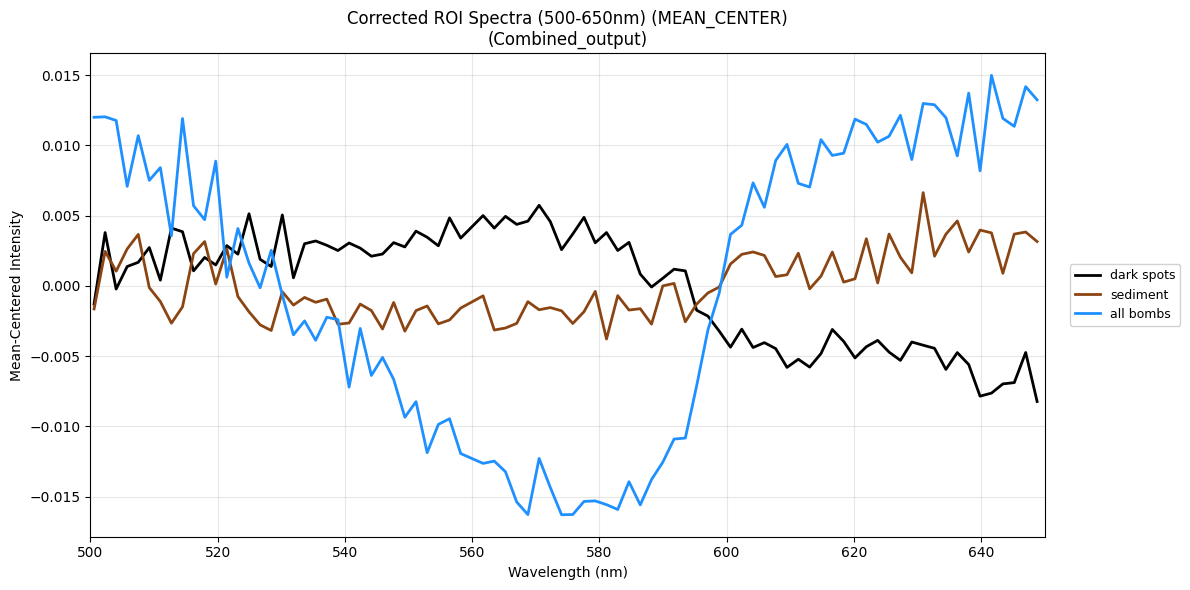

In [31]:
# roi_totals: Mean centering ⭐
cube.plot_spectrum(
    roi_names=roi_totals,
    use_corrected=True,
    wavelength_range=(500, 650),
    wavelength_smoothing=1,
    interpolate_wavelengths=[35, 104, 157],
    normalize_method="mean_center",
    legend_loc="outside",
    use_inline_labels=False,
    show_std=False,
)


🔧 Interpolating 3 wavelength(s):
   • Index 35: 440.31 nm
   • Index 104: 559.97 nm
   • Index 157: 654.20 nm



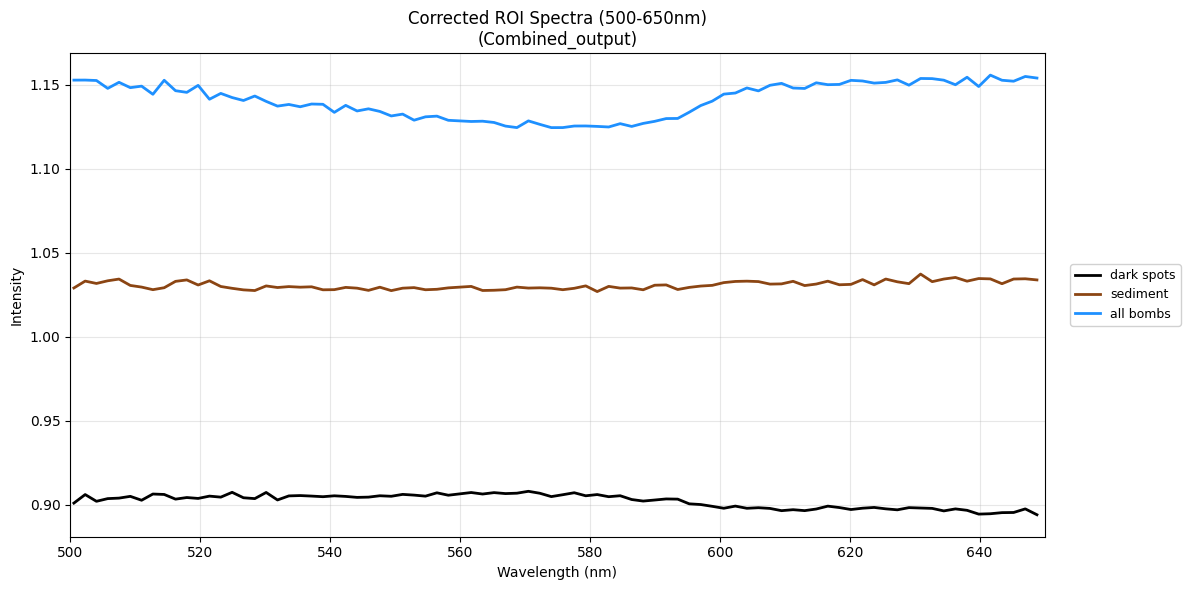

In [32]:
# roi_totals: No normalization
cube.plot_spectrum(
    roi_names=roi_totals,
    use_corrected=True,
    wavelength_range=(500, 650),
    wavelength_smoothing=1,
    interpolate_wavelengths=[35, 104, 157],
    normalize_method=None,
    legend_loc="outside",
    use_inline_labels=False,
    show_std=False,
)

# radiance


🔧 Interpolating 3 wavelength(s):
   • Index 35: 440.31 nm
   • Index 104: 559.97 nm
   • Index 157: 654.20 nm



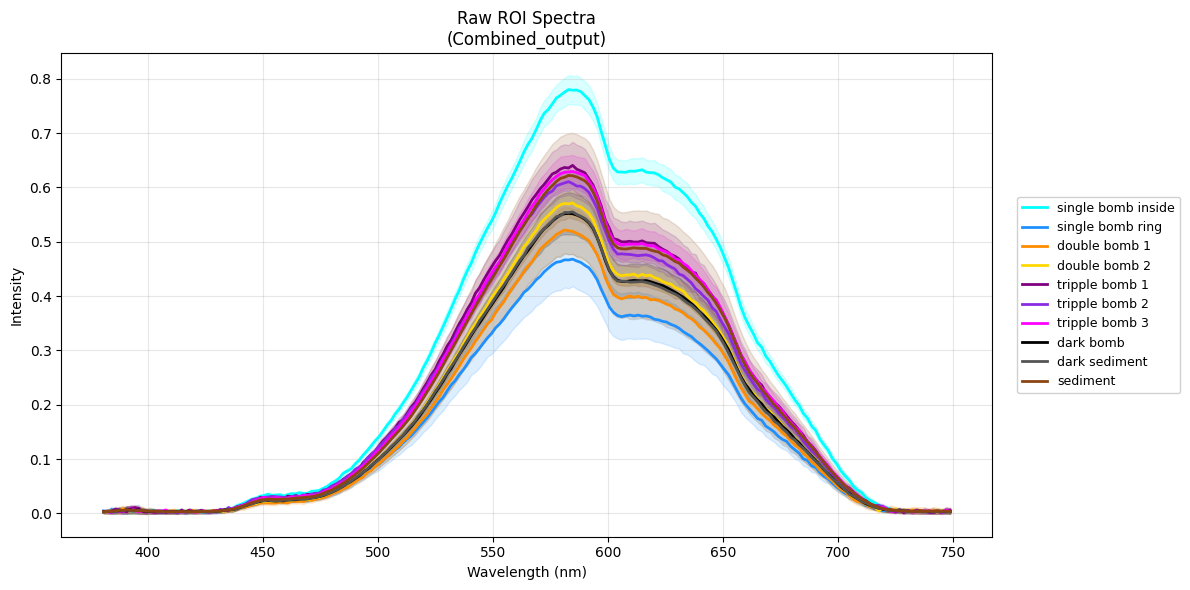

In [33]:
# All ROI spectra with std bands
# Note: ROI colors are now hardcoded in the class!
cube.plot_spectrum(
    roi_names=roi_names,
    use_corrected=False,
    # wavelength_range=(475, 675),
    wavelength_smoothing=0,
    interpolate_wavelengths=[35, 104, 157],
    legend_loc="outside",
    use_inline_labels=False,
)


🔧 Interpolating 3 wavelength(s):
   • Index 35: 440.31 nm
   • Index 104: 559.97 nm
   • Index 157: 654.20 nm



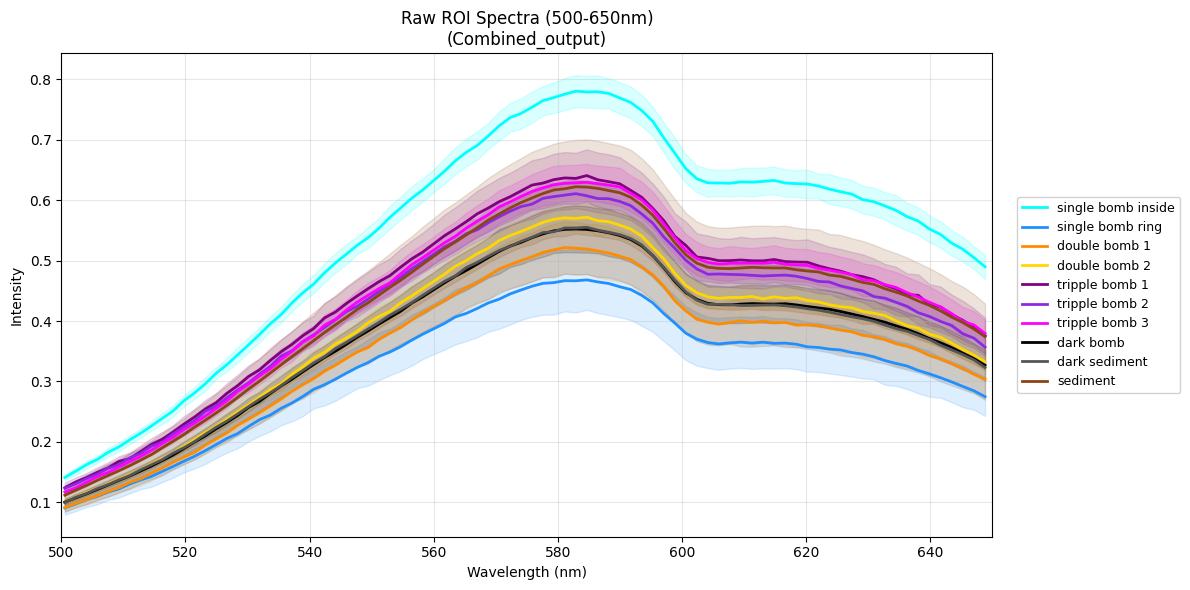

In [34]:
# Test: No normalization (raw data with offset visible)
cube.plot_spectrum(
    roi_names=roi_names,
    use_corrected=False,
    wavelength_range=(500, 650),
    wavelength_smoothing=1,
    interpolate_wavelengths=[35, 104, 157],
    normalize_method=None,  # No normalization
    legend_loc="outside",
    use_inline_labels=False,
    show_std=True,
)


🔧 Interpolating 3 wavelength(s):
   • Index 35: 440.31 nm
   • Index 104: 559.97 nm
   • Index 157: 654.20 nm



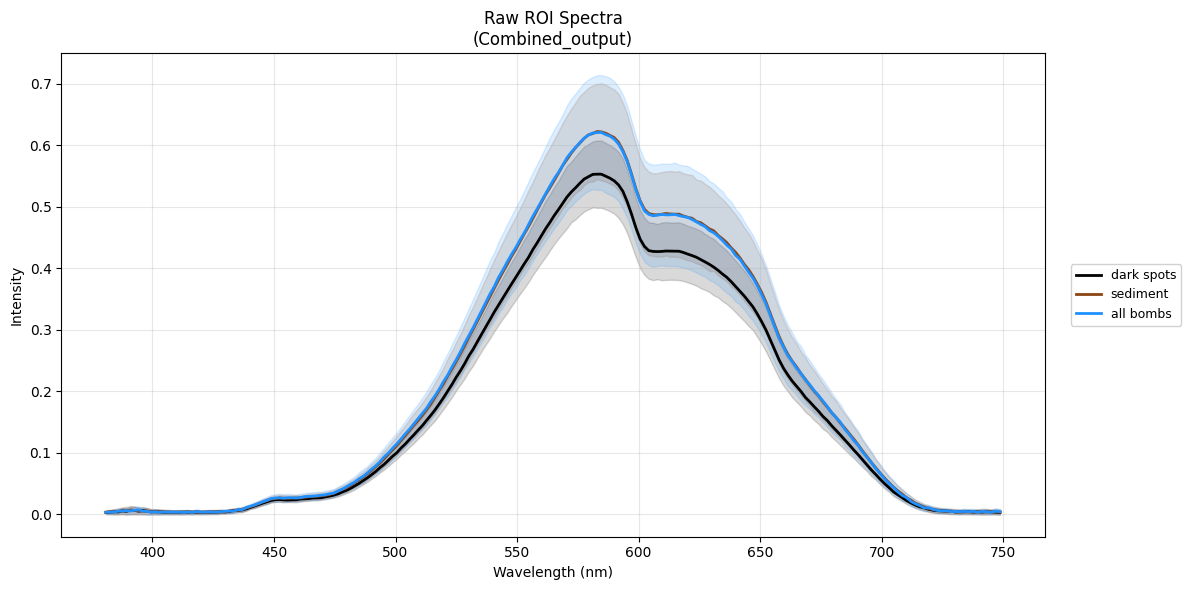

In [35]:
cube.plot_spectrum(
    roi_names=roi_totals,
    use_corrected=False,
    # wavelength_range=(500, 650),
    wavelength_smoothing=1,
    interpolate_wavelengths=[35, 104, 157],
    normalize_method=None,  # No normalization
    legend_loc="outside",
    use_inline_labels=False,
)


🔧 Interpolating 3 wavelength(s):
   • Index 35: 440.31 nm
   • Index 104: 559.97 nm
   • Index 157: 654.20 nm



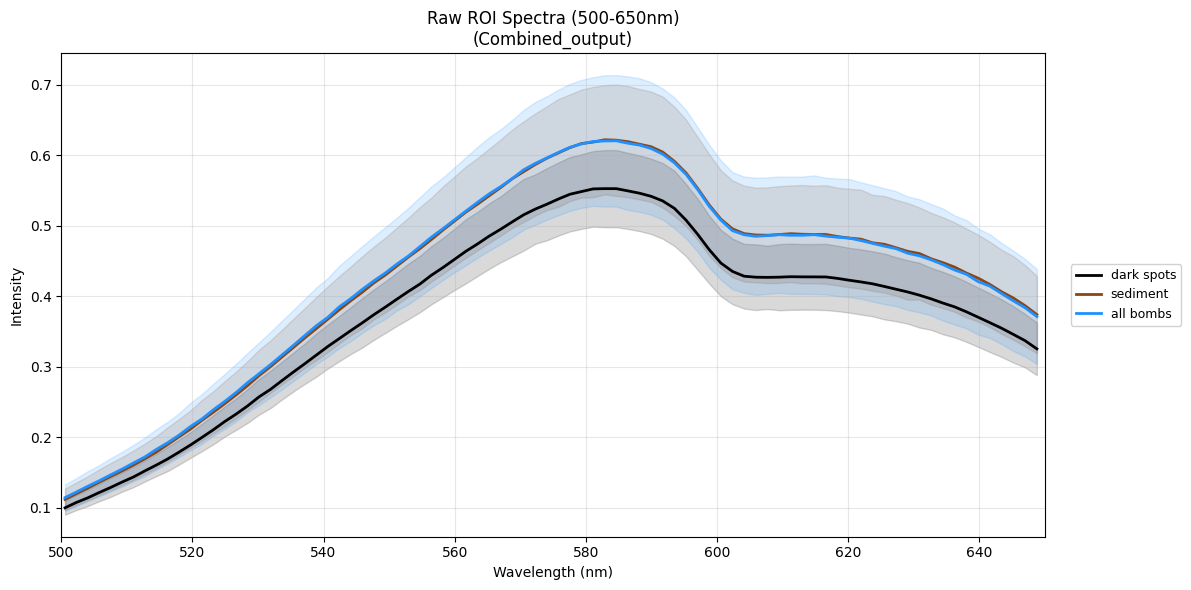

In [36]:
cube.plot_spectrum(
    roi_names=roi_totals,
    use_corrected=False,
    wavelength_range=(500, 650),
    wavelength_smoothing=1,
    interpolate_wavelengths=[35, 104, 157],
    normalize_method=None,  # No normalization
    legend_loc="outside",
    use_inline_labels=False,
)


🔧 Interpolating 3 wavelength(s):
   • Index 35: 440.31 nm
   • Index 104: 559.97 nm
   • Index 157: 654.20 nm



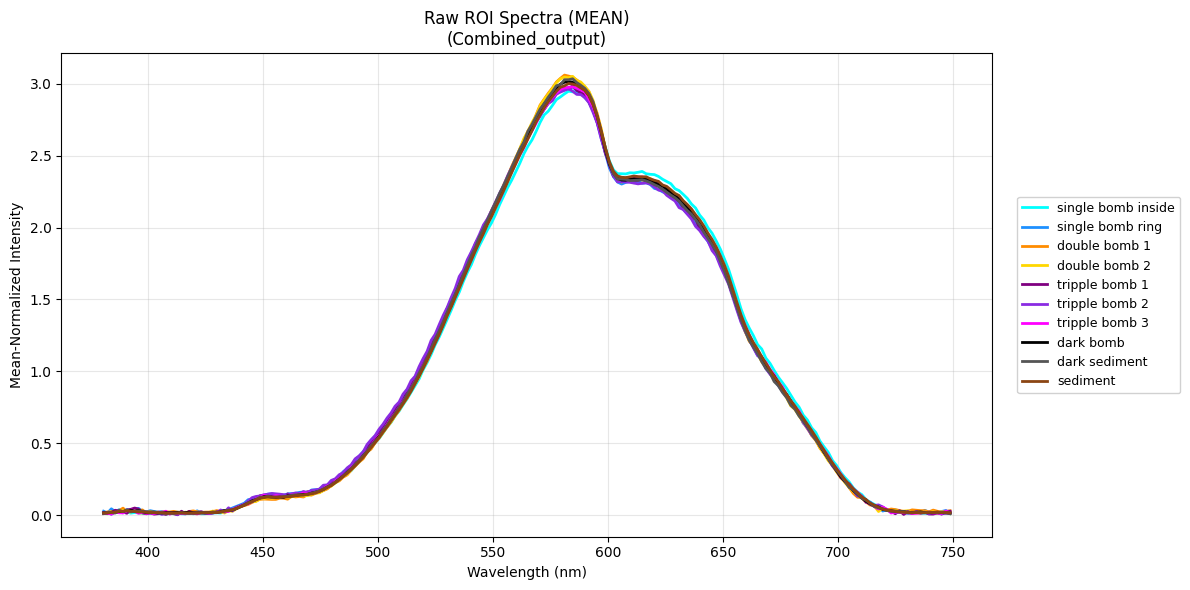

In [37]:
# All ROI spectra with std bands
# Note: ROI colors are now hardcoded in the class!
cube.plot_spectrum(
    roi_names=roi_names,
    use_corrected=False,
    # wavelength_range=(475, 675),
    wavelength_smoothing=0,
    interpolate_wavelengths=[35, 104, 157],
    legend_loc="outside",
    use_inline_labels=False,
    normalize_method="mean",
    show_std=False,
)


🔧 Interpolating 3 wavelength(s):
   • Index 35: 440.31 nm
   • Index 104: 559.97 nm
   • Index 157: 654.20 nm



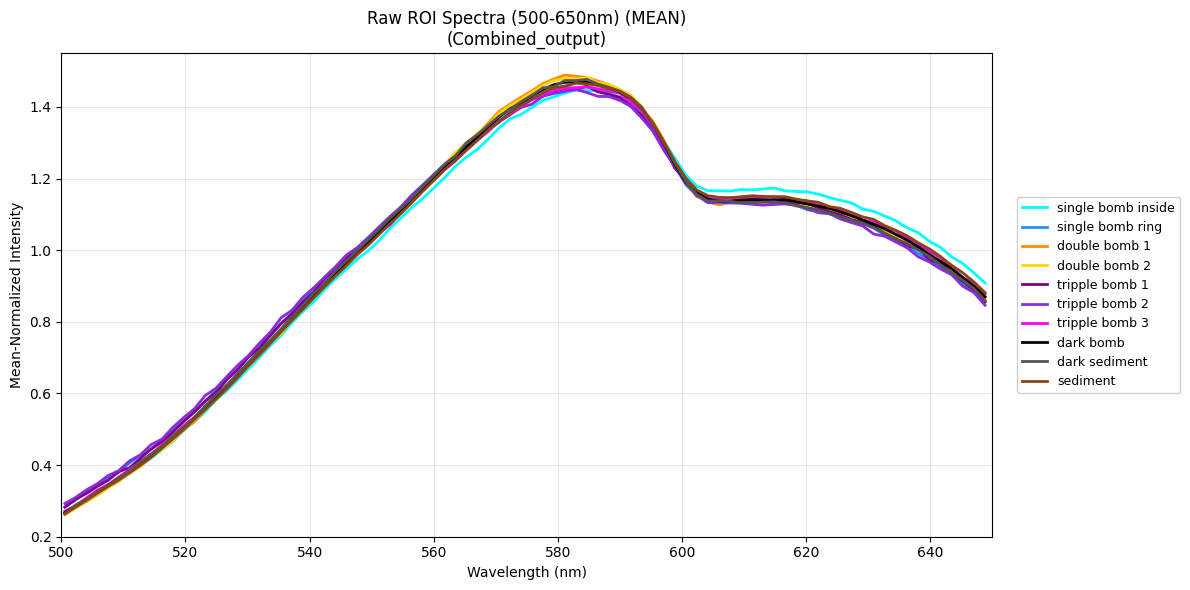

In [38]:
# Test: No normalization (raw data with offset visible)
cube.plot_spectrum(
    roi_names=roi_names,
    use_corrected=False,
    wavelength_range=(500, 650),
    wavelength_smoothing=1,
    interpolate_wavelengths=[35, 104, 157],
    legend_loc="outside",
    use_inline_labels=False,
    show_std=False,
    normalize_method="mean",
)


🔧 Interpolating 3 wavelength(s):
   • Index 35: 440.31 nm
   • Index 104: 559.97 nm
   • Index 157: 654.20 nm



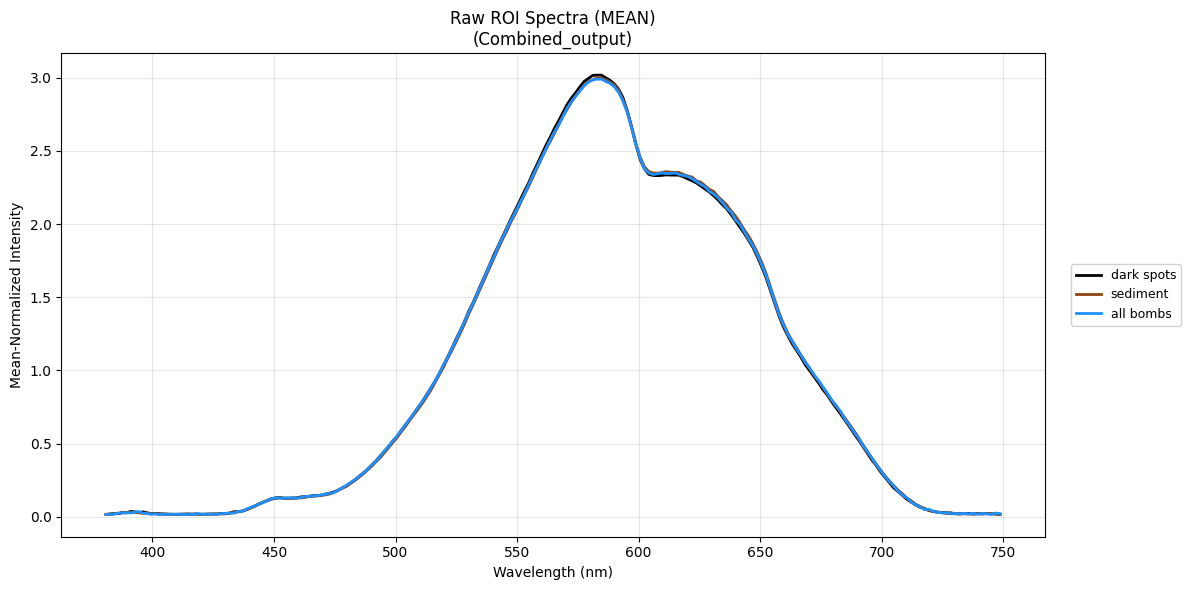

In [41]:
cube.plot_spectrum(
    roi_names=roi_totals,
    use_corrected=False,
    # wavelength_range=(500, 650),
    wavelength_smoothing=1,
    interpolate_wavelengths=[35, 104, 157],
    legend_loc="outside",
    use_inline_labels=False,
    normalize_method="mean",
    show_std=False
)


🔧 Interpolating 3 wavelength(s):
   • Index 35: 440.31 nm
   • Index 104: 559.97 nm
   • Index 157: 654.20 nm

📊 Computing reference spectrum for MSC normalization...
   ✓ Reference computed from 1085 spectra


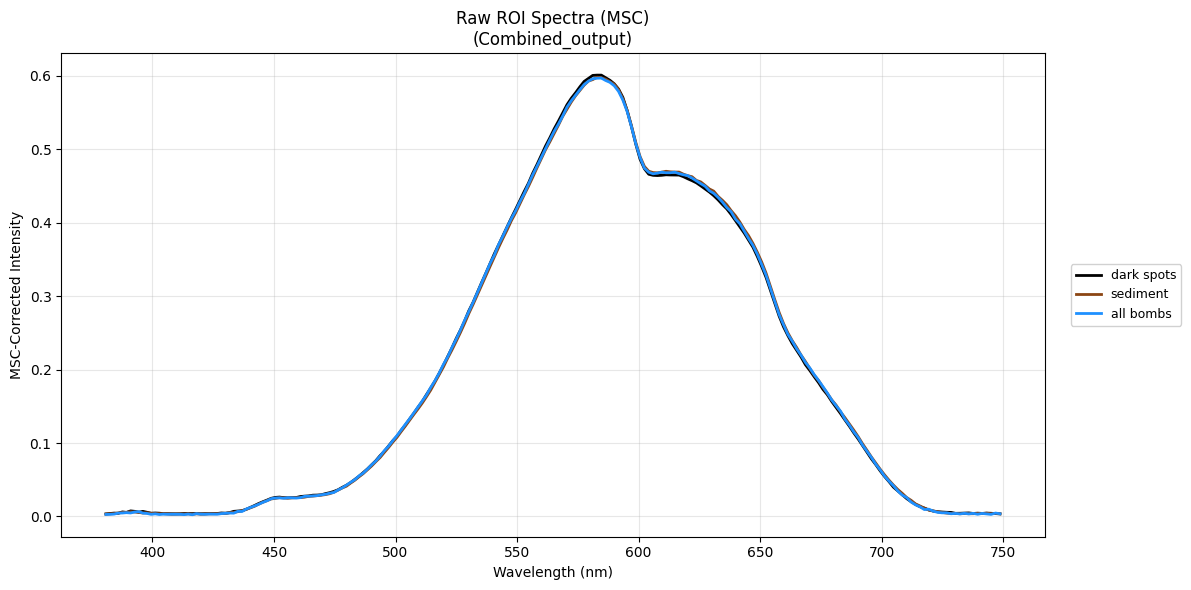

In [42]:
cube.plot_spectrum(
    roi_names=roi_totals,
    use_corrected=False,
    # wavelength_range=(500, 650),
    wavelength_smoothing=1,
    interpolate_wavelengths=[35, 104, 157],
    legend_loc="outside",
    use_inline_labels=False,
    normalize_method="msc",
    show_std=False,
)


🔧 Interpolating 3 wavelength(s):
   • Index 35: 440.31 nm
   • Index 104: 559.97 nm
   • Index 157: 654.20 nm



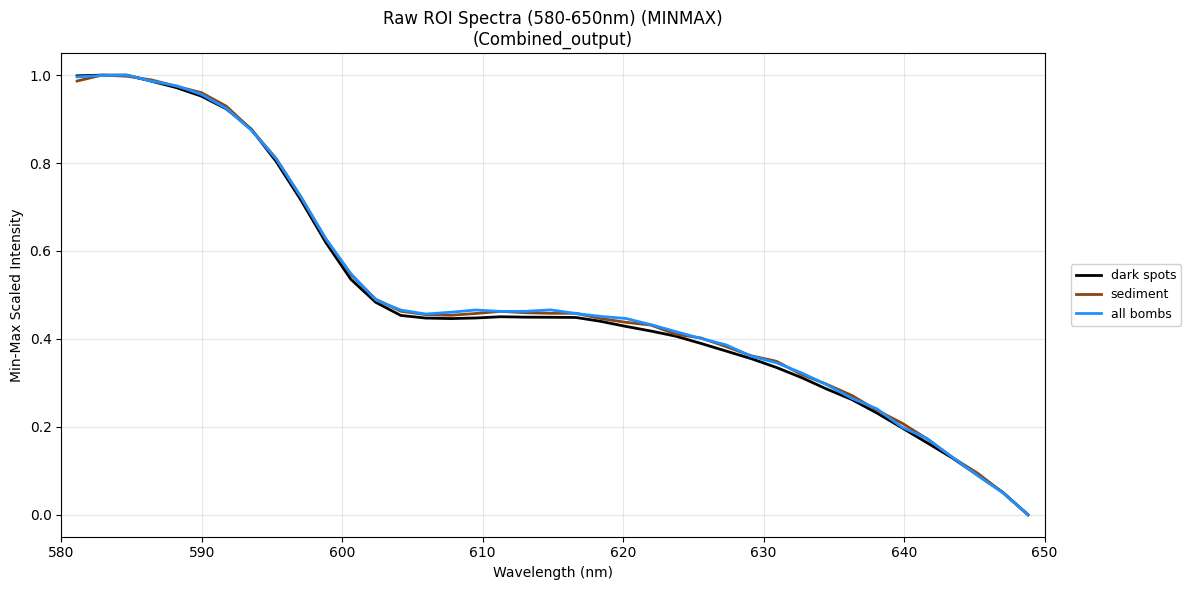

In [48]:
cube.plot_spectrum(
    roi_names=roi_totals,
    use_corrected=False,
    wavelength_range=(580, 650),
    wavelength_smoothing=1,
    interpolate_wavelengths=[35, 104, 157],
    legend_loc="outside",
    use_inline_labels=False,
    normalize_method="minmax",
    show_std=False,
)


🔧 Interpolating 3 wavelength(s):
   • Index 35: 440.31 nm
   • Index 104: 559.97 nm
   • Index 157: 654.20 nm



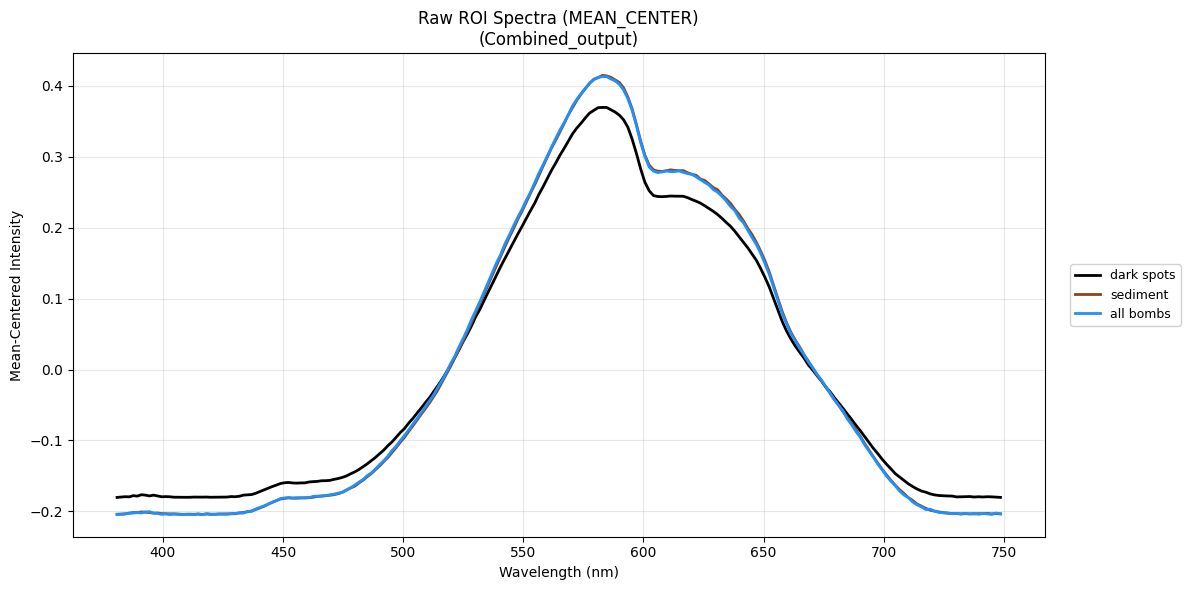

In [44]:
cube.plot_spectrum(
    roi_names=roi_totals,
    use_corrected=False,
    # wavelength_range=(500, 650),
    wavelength_smoothing=1,
    interpolate_wavelengths=[35, 104, 157],
    legend_loc="outside",
    use_inline_labels=False,
    normalize_method="mean_center",
    show_std=False,
)

# extra


🔧 Interpolating 3 wavelength(s):
   • Index 35: 440.31 nm
   • Index 104: 559.97 nm
   • Index 157: 654.20 nm



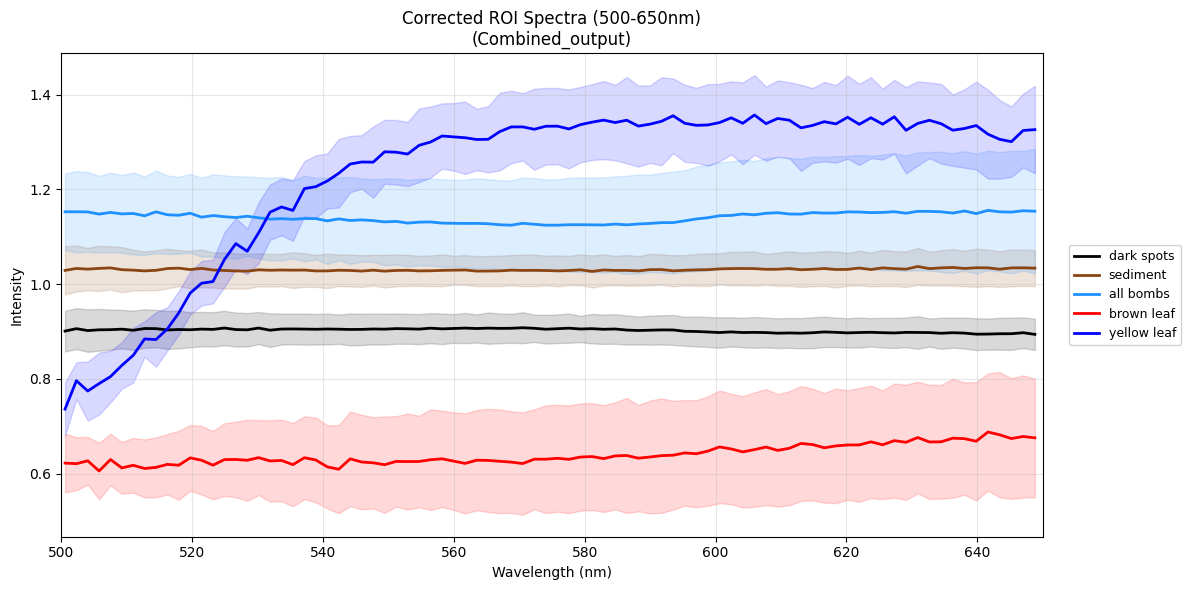

In [ ]:
# Test: No normalization (raw data with offset visible)
cube.plot_spectrum(
    roi_names=roi_extra,
    use_corrected=True,
    wavelength_range=(500, 650),
    wavelength_smoothing=1,
    interpolate_wavelengths=[35, 104, 157],
    normalize_method=None,  # No normalization
    legend_loc="outside",
    use_inline_labels=False,
    show_std=True,
)